In [1]:
# 挂载Drive + 安装依赖
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision opencv-python-headless matplotlib scikit-learn
!pip install -q -e /content/drive/MyDrive/vegetation_models_v2/2_MobileSAM/code

import os, sys
sys.path.insert(0, '/content/drive/MyDrive/vegetation_models_v2/2_MobileSAM/code')
print('✅ 环境准备完成')

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
✅ 环境准备完成


In [6]:
# 数据集类（与SAM2一致，直接复用）
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms

IMG_SIZE = 1024  # MobileSAM强制要求1024x1024

class VegetationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.augment   = augment
        self.images    = []

        all_files = os.listdir(image_dir)
        img_names = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for fname in sorted(img_names):
            img_path  = os.path.join(image_dir, fname)
            stem      = os.path.splitext(fname)[0]
            mask_path = os.path.join(mask_dir, stem + '.png')
            if not os.path.exists(mask_path):
                mask_path = os.path.join(mask_dir, stem + '.jpg')
            if os.path.exists(img_path) and os.path.exists(mask_path):
                self.images.append((img_path, mask_path))

        print(f'  成功配对: {len(self.images)} 张')

        self.img_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406],
                                 std= [0.229,0.224,0.225])
        ])
        self.aug_transform = transforms.Compose([
            transforms.Resize((int(IMG_SIZE*1.05), int(IMG_SIZE*1.05))),
            transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406],
                                 std= [0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, mask_path = self.images[idx]
        img  = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        if self.augment:
            seed = torch.randint(0, 99999, (1,)).item()
            torch.manual_seed(seed)
            img_tensor = self.aug_transform(img)
            torch.manual_seed(seed)
            mask_np = np.array(
                transforms.Compose([
                    transforms.Resize((int(IMG_SIZE*1.05), int(IMG_SIZE*1.05)),
                                      interpolation=Image.NEAREST),
                    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomVerticalFlip(p=0.5),
                ])(mask)
            )
        else:
            img_tensor = self.img_transform(img)
            mask_np    = np.array(mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))

        mask_tensor = torch.from_numpy(mask_np).long()
        mask_tensor = (mask_tensor > 0).long()
        return img_tensor, mask_tensor, os.path.basename(img_path)


DATA_2022 = '/content/drive/MyDrive/datasets/2022-seg'
DATA_2023 = '/content/drive/MyDrive/datasets/2023-seg'
DATA_2024 = '/content/drive/MyDrive/datasets/2024-seg'

print('--- 2022训练集 ---')
ds2022 = VegetationDataset(os.path.join(DATA_2022, 'JPEGImages'),
                            os.path.join(DATA_2022, 'SegmentationClass'), augment=True)
print('--- 2023训练集 ---')
ds2023 = VegetationDataset(os.path.join(DATA_2023, 'JPEGImages'),
                            os.path.join(DATA_2023, 'SegmentationClass'), augment=True)
print('--- 2024测试集 ---')
ds2024 = VegetationDataset(os.path.join(DATA_2024, 'JPEGImages'),
                            os.path.join(DATA_2024, 'SegmentationClass'), augment=False)

train_dataset = ConcatDataset([ds2022, ds2023])
test_dataset  = ds2024

# 1024x1024图像显存占用大，batch适当调小
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'\n✅ 训练集: {len(train_dataset)} 张 | 测试集: {len(test_dataset)} 张')
print(f'   输入尺寸: {IMG_SIZE}x{IMG_SIZE}（MobileSAM要求）')
print(f'   batch_size: 8（1024x1024显存限制，A100约占60GB）')

--- 2022训练集 ---
  成功配对: 67 张
--- 2023训练集 ---
  成功配对: 67 张
--- 2024测试集 ---
  成功配对: 67 张

✅ 训练集: 134 张 | 测试集: 67 张
   输入尺寸: 1024x1024（MobileSAM要求）
   batch_size: 8（1024x1024显存限制，A100约占60GB）


In [7]:
# 构建MobileSAM分割模型
import torch
import torch.nn as nn
from mobile_sam import sam_model_registry

class MobileSAMSeg(nn.Module):
    def __init__(self, ckpt_path, num_classes=2):
        super().__init__()
        sam = sam_model_registry['vit_t'](checkpoint=ckpt_path)
        self.encoder = sam.image_encoder  # 输出 [B, 256, 64, 64]

        self.seg_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1),
            nn.Upsample(size=(1024, 1024),  # 对应输入1024
                        mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        feat = self.encoder(x)
        return self.seg_head(feat)

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = True
        print('🔓 Encoder已解冻，全量微调')


DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT_PATH = '/content/drive/MyDrive/vegetation_models_v2/2_MobileSAM/weights/mobile_sam.pt'

print(f'🔧 设备: {DEVICE}')
model = MobileSAMSeg(CKPT_PATH, num_classes=2).to(DEVICE)

total   = sum(p.numel() for p in model.parameters())
encoder = sum(p.numel() for p in model.encoder.parameters())
head    = sum(p.numel() for p in model.seg_head.parameters())
print(f'✅ 模型加载完成')
print(f'   总参数: {total:,} | Encoder: {encoder:,} | Head: {head:,}')

🔧 设备: cuda
✅ 模型加载完成
   总参数: 7,025,470 | Encoder: 6,065,532 | Head: 959,938


In [8]:
# 损失函数 + 评估函数
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1.0):
    pred   = torch.softmax(pred, dim=1)[:, 1]
    target = target.float()
    inter  = (pred * target).sum(dim=(1,2))
    union  = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return 1 - ((2*inter + smooth) / (union + smooth)).mean()

def focal_loss(pred, target, gamma=2.0, alpha=0.75):
    """Focal Loss 解决植被/背景不平衡"""
    ce   = F.cross_entropy(pred, target, reduction='none')
    pt   = torch.exp(-ce)
    w    = target.float() * alpha + (1 - target.float()) * (1 - alpha)
    return (w * (1 - pt)**gamma * ce).mean()

def combined_loss(pred, target):
    return 0.4 * focal_loss(pred, target) + 0.6 * dice_loss(pred, target)


def evaluate(model, loader, device):
    model.eval()
    iou_list, acc_list, f1_list = [], [], []
    with torch.no_grad():
        for imgs, masks, _ in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = torch.argmax(model(imgs), dim=1)

            tp = ((preds==1) & (masks==1)).sum().item()
            fp = ((preds==1) & (masks==0)).sum().item()
            fn = ((preds==0) & (masks==1)).sum().item()
            tn = ((preds==0) & (masks==0)).sum().item()

            iou = tp / (tp+fp+fn+1e-6)
            acc = (tp+tn) / (tp+fp+fn+tn+1e-6)
            f1  = 2*tp / (2*tp+fp+fn+1e-6)

            iou_list.append(iou)
            acc_list.append(acc)
            f1_list.append(f1)

    return np.mean(iou_list), np.mean(acc_list), np.mean(f1_list)

print('✅ 损失函数和评估函数定义完成')

✅ 损失函数和评估函数定义完成


In [9]:
# 直接全量微调
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import json

SAVE_DIR = '/content/drive/MyDrive/vegetation_models_v2/2_MobileSAM/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_EPOCHS = 100
scaler     = GradScaler()
best_iou   = 0
train_log  = []

# 全量微调，encoder和head都更新
model.unfreeze_encoder()

optimizer = optim.AdamW([
    {'params': model.encoder.parameters(),  'lr': 5e-5},  # encoder小学习率
    {'params': model.seg_head.parameters(), 'lr': 5e-4},  # head大学习率
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('='*60)
print(f'🚀 全量微调，共{NUM_EPOCHS}轮，batch=16，设备: {DEVICE}')
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   可训练参数: {trainable:,}')
print('='*60)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            loss = combined_loss(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    iou, acc, f1 = evaluate(model, test_loader, DEVICE)
    train_log.append({'epoch': epoch, 'loss': avg_loss,
                      'iou': iou, 'acc': acc, 'f1': f1})

    print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}] '
          f'Loss: {avg_loss:.4f} | IoU: {iou:.4f} | '
          f'F1: {f1:.4f} | Acc: {acc:.4f}')

    if iou > best_iou:
        best_iou = iou
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_iou': best_iou
        }, os.path.join(SAVE_DIR, 'mobilesam_best.pth'))
        print(f'  💾 最优模型保存 (IoU={best_iou:.4f})')

with open(os.path.join(SAVE_DIR, 'train_log.json'), 'w') as f:
    json.dump(train_log, f, indent=2)

print('='*60)
print(f'✅ 训练完成！最优IoU: {best_iou:.4f}')

🔓 Encoder已解冻，全量微调
🚀 全量微调，共100轮，batch=16，设备: cuda
   可训练参数: 7,025,470


/tmp/ipython-input-5603/75312891.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()
/tmp/ipython-input-5603/75312891.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [001/100] Loss: 0.2068 | IoU: 0.6098 | F1: 0.7141 | Acc: 0.6099
  💾 最优模型保存 (IoU=0.6098)
Epoch [002/100] Loss: 0.1752 | IoU: 0.6780 | F1: 0.7798 | Acc: 0.7768
  💾 最优模型保存 (IoU=0.6780)
Epoch [003/100] Loss: 0.1529 | IoU: 0.7204 | F1: 0.8188 | Acc: 0.8461
  💾 最优模型保存 (IoU=0.7204)
Epoch [004/100] Loss: 0.1527 | IoU: 0.7369 | F1: 0.8322 | Acc: 0.8595
  💾 最优模型保存 (IoU=0.7369)
Epoch [005/100] Loss: 0.1359 | IoU: 0.6889 | F1: 0.8003 | Acc: 0.8298
Epoch [006/100] Loss: 0.1388 | IoU: 0.7276 | F1: 0.8264 | Acc: 0.8606
Epoch [007/100] Loss: 0.1382 | IoU: 0.7289 | F1: 0.8272 | Acc: 0.8642
Epoch [008/100] Loss: 0.1334 | IoU: 0.7355 | F1: 0.8325 | Acc: 0.8653
Epoch [009/100] Loss: 0.1253 | IoU: 0.7302 | F1: 0.8288 | Acc: 0.8618
Epoch [010/100] Loss: 0.1162 | IoU: 0.6952 | F1: 0.7985 | Acc: 0.8535
Epoch [011/100] Loss: 0.1086 | IoU: 0.7006 | F1: 0.8039 | Acc: 0.8532
Epoch [012/100] Loss: 0.1178 | IoU: 0.7207 | F1: 0.8199 | Acc: 0.8628
Epoch [013/100] Loss: 0.1043 | IoU: 0.7082 | F1: 0.8113 | Acc: 0

In [11]:
# 测试集评估 + 可视化
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ckpt = torch.load(os.path.join(SAVE_DIR, 'mobilesam_best.pth'),
                  map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'✅ 加载最优模型 (epoch={ckpt["epoch"]}, IoU={ckpt["best_iou"]:.4f})')

test_iou, test_acc, test_f1 = evaluate(model, test_loader, DEVICE)
print(f'\n📊 2024测试集最终结果:')
print(f'   mIoU:           {test_iou:.4f}')
print(f'   F1 Score:       {test_f1:.4f}')
print(f'   Pixel Accuracy: {test_acc:.4f}')

# 可视化前6张
model.eval()
fig, axes = plt.subplots(6, 3, figsize=(12, 24))
axes[0][0].set_title('原图',     fontsize=13)
axes[0][1].set_title('真实标注', fontsize=13)
axes[0][2].set_title('模型预测', fontsize=13)

count = 0
with torch.no_grad():
    for imgs, masks, names in test_loader:
        preds = torch.argmax(model(imgs.to(DEVICE)), dim=1).cpu()
        for i in range(imgs.size(0)):
            if count >= 6: break
            img_np = imgs[i].permute(1,2,0).numpy()
            img_np = np.clip(img_np * np.array([0.229,0.224,0.225])
                             + np.array([0.485,0.456,0.406]), 0, 1)
            axes[count][0].imshow(img_np)
            axes[count][0].set_ylabel(names[i], fontsize=7, rotation=0, labelpad=60)
            axes[count][1].imshow(masks[i].numpy(), cmap='Greens', vmin=0, vmax=1)
            axes[count][2].imshow(preds[i].numpy(), cmap='Greens', vmin=0, vmax=1)
            for ax in axes[count]: ax.axis('off')
            count += 1
        if count >= 6: break

fig.legend(handles=[
    mpatches.Patch(color='green', label='植被'),
    mpatches.Patch(color='black', label='背景')
], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.01))
plt.suptitle(f'MobileSAM 2024测试集结果\n'
             f'IoU={test_iou:.4f} | F1={test_f1:.4f} | Acc={test_acc:.4f}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mobilesam_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 可视化已保存')

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-5603/1835742660.py:24: UserWarning: Glyph 39564 (\N

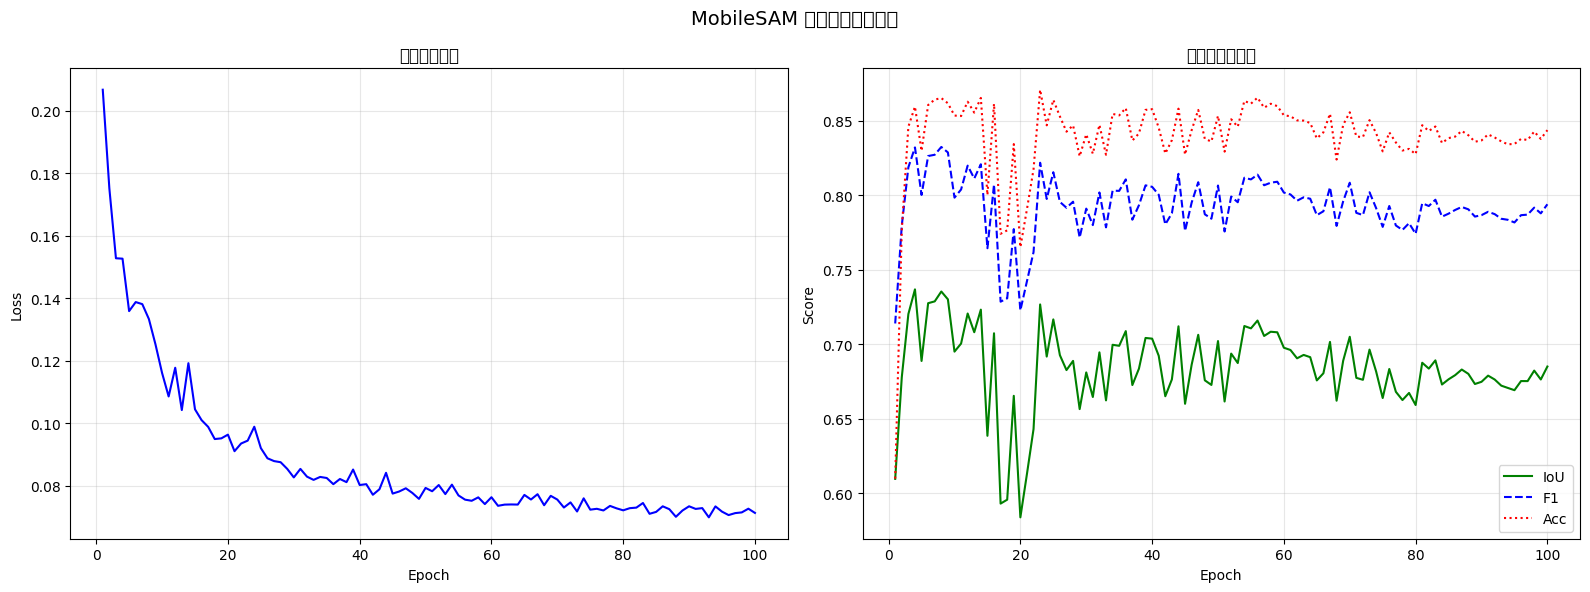

✅ 训练曲线已保存


In [12]:
# 训练曲线
import matplotlib.pyplot as plt

log    = train_log
epochs = [x['epoch'] for x in log]
losses = [x['loss']  for x in log]
ious   = [x['iou']   for x in log]
f1s    = [x['f1']    for x in log]
accs   = [x['acc']   for x in log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs, losses, 'b-', linewidth=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('训练损失曲线'); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, ious, 'g-',  linewidth=1.5, label='IoU')
ax2.plot(epochs, f1s,  'b--', linewidth=1.5, label='F1')
ax2.plot(epochs, accs, 'r:',  linewidth=1.5, label='Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('验证集指标曲线'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('MobileSAM 全量微调训练过程', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mobilesam_train_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ 训练曲线已保存')